In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

rijubera2000_poaching_and_animal_detection_dataset_path = kagglehub.dataset_download('rijubera2000/poaching-and-animal-detection-dataset')
vrushikakpanchal_dataset_02_path = kagglehub.dataset_download('vrushikakpanchal/dataset-02')
vrushikakpanchal_test_img_path = kagglehub.dataset_download('vrushikakpanchal/test-img')

print('Data source import complete.')


In [ ]:
# STEP 1: Imports and Setup
import os
import shutil
import random
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

In [ ]:
# Directory Setup
output_dir = Path("/kaggle/working/wildlife_classification")
for split in ["train", "val", "test"]:
    (output_dir / split).mkdir(parents=True, exist_ok=True)

# Source Dataset Paths
kaggle_base = Path("/kaggle/input/poaching-and-animal-detection-dataset/Project Dataset for Animal Prediction")
roboflow_base = Path("/kaggle/input/dataset-02")

In [ ]:
# Full label normalization and mapping dictionary

label_mapping = {
    # 🐾 Wild Animals
    'lion': 'Wild Animal - Lion',
    'Lion': 'Wild Animal - Lion',
    'tiger': 'Wild Animal - Tiger',
    'Tiger': 'Wild Animal - Tiger',
    'cheetah': 'Wild Animal - Cheetah',
    'Cheetah': 'Wild Animal - Cheetah',
    'leopard': 'Wild Animal - Leopard',
    'Jaguar': 'Wild Animal - Jaguar',
    'girafee': 'Wild Animal - Giraffe',
    'Giraffe': 'Wild Animal - Giraffe',
    'elephant': 'Wild Animal - Elephant',
    'Elephant': 'Wild Animal - Elephant',
    'zebra': 'Wild Animal - Zebra',
    'Zebra': 'Wild Animal - Zebra',
    'hippo': 'Wild Animal - Hippopotamus',
    'Hippopotamus': 'Wild Animal - Hippopotamus',
    'rhino': 'Wild Animal - Rhinoceros',
    'Rhinoceros': 'Wild Animal - Rhinoceros',
    'bear': 'Wild Animal - Bear',
    'Bear': 'Wild Animal - Bear',
    'Brown bear': 'Wild Animal - Bear',
    'Polar bear': 'Wild Animal - Bear',
    'fox': 'Wild Animal - Fox',
    'Fox': 'Wild Animal - Fox',
    'deer': 'Wild Animal - Deer',
    'Deer': 'Wild Animal - Deer',
    'pig': 'Wild Animal - Pig',
    'Pig': 'Wild Animal - Pig',
    'bull': 'Wild Animal - Bull',
    'Bull': 'Wild Animal - Bull',
    'Camel': 'Wild Animal - Camel',
    'camel': 'Wild Animal - Camel',
    'Cattle': 'Wild Animal - Bull',
    'Horse': 'Wild Animal - Horse',
    'Mule': 'Wild Animal - Mule',
    'Goat': 'Wild Animal - Goat',
    'Kangaroo': 'Wild Animal - Kangaroo',
    'Koala': 'Wild Animal - Koala',
    'Otter': 'Wild Animal - Otter',
    'Raccoon': 'Wild Animal - Raccoon',
    'Red panda': 'Wild Animal - Red Panda',
    'Hedgehog': 'Wild Animal - Hedgehog',
    'Mouse': 'Wild Animal - Mouse',
    'Lynx': 'Wild Animal - Lynx',
    'Hamster': 'Wild Animal - Hamster',
    'Squirrel': 'Wild Animal - Squirrel',
    'Panda': 'Wild Animal - Panda',

    # 🧍 Human
    'poacher': 'Human - Poacher',
    'Poacher': 'Human - Poacher',
    'ranger': 'Human - Ranger',
    'Ranger': 'Human - Ranger',

    # 🔫 Weapon
    'weapon': 'Weapon',
    'Weapon': 'Weapon',

    # 🐒 Monkey
    'monkey': 'Wild Animal - Monkey',
    'Monkey': 'Wild Animal - Monkey',

    # 🐦 Birds
    'Turkey': 'Bird - Turkey',
    'turkey': 'Bird - Turkey',
    'Eagle': 'Bird - Eagle',
    'Owl': 'Bird - Owl',
    'Parrot': 'Bird - Parrot',
    'Sparrow': 'Bird - Sparrow',
    'Canary': 'Bird - Canary',
    'Goose': 'Bird - Goose',
    'Chicken': 'Bird - Chicken',
    'Duck': 'Bird - Duck',
    'Raven': 'Bird - Raven',
    'Magpie': 'Bird - Magpie',
    'Woodpecker': 'Bird - Woodpecker',
    'Swan': 'Bird - Swan',
    'Ostrich': 'Bird - Ostrich',

    # 🐛 Insects
    'Butterfly': 'Insect - Butterfly',
    'Moths and butterflies': 'Insect - Butterfly',
    'Caterpillar': 'Insect - Caterpillar',
    'Centipede': 'Insect - Centipede',
    'Ladybug': 'Insect - Ladybug',
    'Tick': 'Insect - Tick',
    'Scorpion': 'Insect - Scorpion',
    'Spider': 'Insect - Spider',
    'Worm': 'Insect - Worm',

    # 🐟 Marine Life
    'Fish': 'Marine Animal - Fish',
    'Shark': 'Marine Animal - Shark',
    'Sea turtle': 'Marine Animal - Sea Turtle',
    'Turtle': 'Marine Animal - Turtle',
    'Tortoise': 'Marine Animal - Tortoise',
    'Seahorse': 'Marine Animal - Seahorse',
    'Crab': 'Marine Animal - Crab',
    'Shrimp': 'Marine Animal - Shrimp',
    'Squid': 'Marine Animal - Squid',
    'Jellyfish': 'Marine Animal - Jellyfish',
    'Whale': 'Marine Animal - Whale',
    'Sea lion': 'Marine Animal - Sea Lion',
    'Harbor seal': 'Marine Animal - Seal',
    'Starfish': 'Marine Animal - Starfish',
    'Goldfish': 'Marine Animal - Fish',

    # 🦎 Reptiles & Amphibians
    'Snake': 'Reptile - Snake',
    'Lizard': 'Reptile - Lizard',
    'Frog': 'Amphibian - Frog',

    # ⚠️ Fallback
    'animal': 'Wild Animal - Unknown',
    'dog': 'Wild Animal - Dog',  # domesticated
    'Cat': 'Wild Animal - Cat',  # if present
    'unknown': 'Wild Animal - Unknown'
}

# Normalize label from filename
def infer_label_from_filename(filename):
    name = filename.lower()
    for key in label_mapping:
        if key.lower() in name:
            return label_mapping[key]
    return None

# Create class list from unique mapped values
unique_classes = sorted(set(label_mapping.values()))
class_to_index = {name: i for i, name in enumerate(unique_classes)}
index_to_class = {v: k for k, v in class_to_index.items()}

# ✔ Example of using it:
print("Total Classes:", len(class_to_index))
for i, name in enumerate(unique_classes):
    print(f"{i}: {name}")


Total Classes: 76
0: Amphibian - Frog
1: Bird - Canary
2: Bird - Chicken
3: Bird - Duck
4: Bird - Eagle
5: Bird - Goose
6: Bird - Magpie
7: Bird - Ostrich
8: Bird - Owl
9: Bird - Parrot
10: Bird - Raven
11: Bird - Sparrow
12: Bird - Swan
13: Bird - Turkey
14: Bird - Woodpecker
15: Human - Poacher
16: Human - Ranger
17: Insect - Butterfly
18: Insect - Caterpillar
19: Insect - Centipede
20: Insect - Ladybug
21: Insect - Scorpion
22: Insect - Spider
23: Insect - Tick
24: Insect - Worm
25: Marine Animal - Crab
26: Marine Animal - Fish
27: Marine Animal - Jellyfish
28: Marine Animal - Sea Lion
29: Marine Animal - Sea Turtle
30: Marine Animal - Seahorse
31: Marine Animal - Seal
32: Marine Animal - Shark
33: Marine Animal - Shrimp
34: Marine Animal - Squid
35: Marine Animal - Starfish
36: Marine Animal - Tortoise
37: Marine Animal - Turtle
38: Marine Animal - Whale
39: Reptile - Lizard
40: Reptile - Snake
41: Weapon
42: Wild Animal - Bear
43: Wild Animal - Bull
44: Wild Animal - Camel
45: Wil

In [ ]:
# STEP 2: Organize Kaggle Dataset (train/test) & manually split val
def organize_kaggle_split(base_dir, split_name, val_split=False):
    for class_dir in os.listdir(base_dir):
        source = base_dir / class_dir
        if not source.is_dir():
            continue
        label = label_mapping.get(class_dir, None)
        if not label:
            continue
        files = [f for f in os.listdir(source) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if val_split:
            random.shuffle(files)
            split_idx = int(len(files) * 0.8)
            files_train = files[:split_idx]
            files_val = files[split_idx:]
            for file in files_train:
                shutil.copy(source / file, output_dir / "train" / label / file)
            for file in files_val:
                shutil.copy(source / file, output_dir / "val" / label / file)
        else:
            for file in files:
                shutil.copy(source / file, output_dir / split_name / label / file)

In [ ]:
# STEP 3: Organize Roboflow flat folders
def organize_roboflow_flat(src_dir, split_name):
    for file in os.listdir(src_dir):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            label = infer_label_from_filename(file)
            if not label:
                continue
            shutil.copy(src_dir / file, output_dir / split_name / label / file)

# Create required label folders first
for split in ["train", "val", "test"]:
    for label in unique_classes:
        (output_dir / split / label).mkdir(parents=True, exist_ok=True)

# Organize all data
organize_kaggle_split(kaggle_base / "train", "train", val_split=True)
organize_kaggle_split(kaggle_base / "test", "test", val_split=False)
organize_roboflow_flat(roboflow_base / "train/images", "train")
organize_roboflow_flat(roboflow_base / "valid/images", "val")
organize_roboflow_flat(roboflow_base / "test/images", "test")

print("✅ Dataset organized.")

✅ Dataset organized.


In [ ]:
# STEP 4: Dataset & DataLoaders
# Remove empty folders from each split (train/val/test)
def remove_empty_class_dirs(split_path):
    for class_dir in split_path.iterdir():
        if class_dir.is_dir() and not any(class_dir.glob("*")):
            print(f"Removing empty class directory: {class_dir}")
            shutil.rmtree(class_dir)

for split in ["train", "val", "test"]:
    remove_empty_class_dirs(output_dir / split)

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(output_dir / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(output_dir / "val", transform=val_test_transform)
test_dataset = datasets.ImageFolder(output_dir / "test", transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ Datasets loaded.")
print("Classes:", train_dataset.classes)

✅ Datasets loaded.
Classes: ['Amphibian - Frog', 'Bird - Canary', 'Bird - Chicken', 'Bird - Duck', 'Bird - Eagle', 'Bird - Goose', 'Bird - Magpie', 'Bird - Ostrich', 'Bird - Owl', 'Bird - Parrot', 'Bird - Raven', 'Bird - Sparrow', 'Bird - Swan', 'Bird - Turkey', 'Bird - Woodpecker', 'Human - Poacher', 'Human - Ranger', 'Insect - Butterfly', 'Insect - Caterpillar', 'Insect - Centipede', 'Insect - Ladybug', 'Insect - Scorpion', 'Insect - Spider', 'Insect - Tick', 'Insect - Worm', 'Marine Animal - Crab', 'Marine Animal - Fish', 'Marine Animal - Jellyfish', 'Marine Animal - Sea Lion', 'Marine Animal - Sea Turtle', 'Marine Animal - Seahorse', 'Marine Animal - Seal', 'Marine Animal - Shark', 'Marine Animal - Shrimp', 'Marine Animal - Squid', 'Marine Animal - Starfish', 'Marine Animal - Tortoise', 'Marine Animal - Turtle', 'Marine Animal - Whale', 'Reptile - Lizard', 'Reptile - Snake', 'Wild Animal - Bear', 'Wild Animal - Bull', 'Wild Animal - Camel', 'Wild Animal - Cheetah', 'Wild Animal - D

# **ResNet18**

In [ ]:
# ------------------------------------------
# ✅ STEP 3: Improved Model (ResNet18)
# ------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


In [ ]:
# ------------------------------------------
# ✅ STEP 4: Training & Evaluation
# ------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

def evaluate_model(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def train_model(epochs=30):
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        val_acc = evaluate_model(val_loader)
        print(f"Epoch {epoch+1} | Loss: {running_loss:.4f} | Train Acc: {100*correct/total:.2f}% | Val Acc: {val_acc:.2f}%")

print("\n🚀 Training started...")
train_model(epochs=30)

print("\n✅ Final Test Accuracy:", evaluate_model(test_loader), "%")


🚀 Training started...
Epoch 1 | Loss: 1291.7563 | Train Acc: 47.07% | Val Acc: 47.01%
Epoch 2 | Loss: 937.8232 | Train Acc: 58.96% | Val Acc: 52.79%
Epoch 3 | Loss: 804.7422 | Train Acc: 63.67% | Val Acc: 54.41%
Epoch 4 | Loss: 695.9772 | Train Acc: 67.71% | Val Acc: 55.54%
Epoch 5 | Loss: 620.0499 | Train Acc: 70.95% | Val Acc: 60.24%
Epoch 6 | Loss: 550.9204 | Train Acc: 73.68% | Val Acc: 62.87%
Epoch 7 | Loss: 483.9637 | Train Acc: 76.40% | Val Acc: 65.50%
Epoch 8 | Loss: 432.3840 | Train Acc: 78.40% | Val Acc: 63.91%
Epoch 9 | Loss: 387.2535 | Train Acc: 80.41% | Val Acc: 65.90%
Epoch 10 | Loss: 356.7091 | Train Acc: 82.03% | Val Acc: 65.76%
Epoch 11 | Loss: 316.2486 | Train Acc: 83.61% | Val Acc: 67.52%
Epoch 12 | Loss: 302.9406 | Train Acc: 84.25% | Val Acc: 66.12%
Epoch 13 | Loss: 289.1197 | Train Acc: 84.49% | Val Acc: 67.64%
Epoch 14 | Loss: 257.2638 | Train Acc: 86.35% | Val Acc: 68.31%
Epoch 15 | Loss: 243.7113 | Train Acc: 86.96% | Val Acc: 68.78%
Epoch 16 | Loss: 235.6146

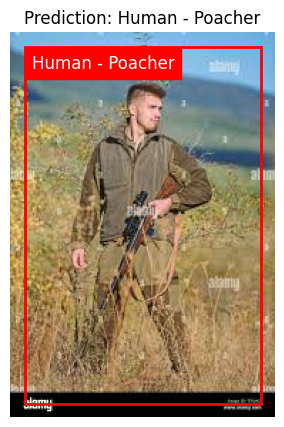

In [ ]:
# ------------------------------------------
# ✅ STEP 5: Predict on Unseen Image + Draw Box
# ------------------------------------------
from torchvision import transforms as T
import matplotlib.patches as patches

def predict_and_draw(img_path):
    image = Image.open(img_path).convert("RGB")
    img_tensor = val_test_transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
        label = train_dataset.classes[pred.item()]

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    ax = plt.gca()
    rect = patches.Rectangle((10, 10), image.size[0]-20, image.size[1]-20, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    plt.text(15, 25, label, color='white', backgroundcolor='red', fontsize=12)
    plt.axis('off')
    plt.title(f"Prediction: {label}")
    plt.show()

# Example usage:
predict_and_draw("/kaggle/input/test-img/test_poacher.jpeg")

In [ ]:
# Save the model
model_path = "/kaggle/working/wildlife_resnet_model.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved to: {model_path}")

✅ Model saved to: /kaggle/working/wildlife_resnet_model.pth


In [ ]:
import os
from IPython.display import FileLink

# Check if file exists
model_path = "/kaggle/working/wildlife_resnet_model.pth"
if os.path.exists(model_path):
    display(FileLink(model_path))
else:
    print("❌ Model file not found. Check the path.")


/kaggle/working/wildlife_resnet_model.pth

# **CNN**

In [ ]:
# STEP 5: Model Definition
class WildlifeCNN(nn.Module):
    def __init__(self, num_classes):
        super(WildlifeCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = WildlifeCNN(num_classes=len(train_dataset.classes)).to(device)

# STEP 6: Training Loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def evaluate_model(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def train_model(epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        val_acc = evaluate_model(val_loader)
        print(f"Epoch {epoch+1} | Loss: {running_loss:.4f} | Train Acc: {100*correct/total:.2f}% | Val Acc: {val_acc:.2f}%")

# Train the model
train_model(epochs=10)

Epoch 1 | Loss: 1915.4620 | Train Acc: 17.67% | Val Acc: 18.55%
Epoch 2 | Loss: 1787.3396 | Train Acc: 20.47% | Val Acc: 20.60%
Epoch 3 | Loss: 1689.8310 | Train Acc: 22.37% | Val Acc: 21.01%
Epoch 4 | Loss: 1613.8165 | Train Acc: 24.53% | Val Acc: 22.62%
Epoch 5 | Loss: 1521.1404 | Train Acc: 27.11% | Val Acc: 24.97%
Epoch 6 | Loss: 1405.0167 | Train Acc: 31.23% | Val Acc: 24.55%
Epoch 7 | Loss: 1272.3726 | Train Acc: 36.41% | Val Acc: 26.13%
Epoch 8 | Loss: 1105.8949 | Train Acc: 42.45% | Val Acc: 25.83%
Epoch 9 | Loss: 950.0460 | Train Acc: 49.42% | Val Acc: 26.11%
Epoch 10 | Loss: 784.8966 | Train Acc: 57.27% | Val Acc: 25.69%
